# Experiment 3: Ours (joint rating + uncertainty), r x lambda

`S = A B^T` (rating head) and `U = C D^T` (uncertainty head), trained
jointly per proposal eq. (4)-(5): each example's rating-loss term is
down-weighted by `exp(-U)`, while `lambda * U` penalises the model for
claiming low confidence too cheaply. Same plain per-example SGD style as
Experiments 1-2, mean-centered, worked out by hand instead of PyTorch/
autodiff (see `mf_grid.train_ours_mf`'s docstring for the derivation) -
the batched autodiff version lives in `experiments/run_ours.py`.

**Note on the lambda grid below**: this lambda plays a different role
than Experiment 2's Lasso lambda (it penalises the *uncertainty* term,
not embedding magnitude), and the real overnight PyTorch sweep in
`experiments/run_ours.py` already found lambda=0.001 winning on most
datasets - a much smaller natural scale than Lasso's 0-0.5 range. So this
grid keeps the same "sparse near 0, dense near the upper bound" shape but
scaled down to 0-0.05 instead - change it back to 0-0.5 if you actually
want the same numbers as Experiment 2.

In [1]:
import mf_grid
import numpy as np
import matplotlib.pyplot as plt

print(f"CPU cores available for the pool: {mf_grid.N_THREADS}")

CPU cores available for the pool: 6


In [2]:
data = mf_grid.load_ml100k()
print(f"{data['n_users']} users x {data['n_movies']} movies")
print(f"train={len(data['train_r']):,} val={len(data['val_r']):,} test={len(data['test_r']):,}")

610 users x 9724 movies
train=70,585 val=20,167 test=10,084


In [3]:
r_values = [1, 2, 3, 4, 5, 10, 20, 50, 100]
# sparse near 0, narrowing hard approaching 0.05 - see intro note on scale
lam_values = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.045, 0.05]
EPOCHS = 30

configs = [{"r": r, "lam": lam} for r in r_values for lam in lam_values]
print(f"{len(configs)} configs ({len(r_values)} r x {len(lam_values)} lambda)")
results = mf_grid.grid_search(configs, data, mf_grid._pool_run_ours, epochs=EPOCHS, workers=mf_grid.N_THREADS)

99 configs (9 r x 11 lambda)
[1/99] {'r': 1, 'lam': 0.0} -> val RMSE=1.0442 (39.5s)
[2/99] {'r': 1, 'lam': 0.0001} -> val RMSE=1.0442 (40.4s)
[3/99] {'r': 1, 'lam': 0.0005} -> val RMSE=1.0442 (39.7s)
[4/99] {'r': 1, 'lam': 0.001} -> val RMSE=1.0442 (40.0s)
[5/99] {'r': 1, 'lam': 0.005} -> val RMSE=1.0443 (40.4s)
[6/99] {'r': 1, 'lam': 0.01} -> val RMSE=1.0443 (40.6s)
[7/99] {'r': 2, 'lam': 0.0} -> val RMSE=1.0401 (32.6s)
[8/99] {'r': 1, 'lam': 0.02} -> val RMSE=1.0444 (41.2s)
[9/99] {'r': 1, 'lam': 0.03} -> val RMSE=1.0445 (39.8s)
[10/99] {'r': 1, 'lam': 0.04} -> val RMSE=1.0445 (40.2s)
[11/99] {'r': 1, 'lam': 0.045} -> val RMSE=1.0445 (40.0s)
[12/99] {'r': 1, 'lam': 0.05} -> val RMSE=1.0445 (39.8s)
[13/99] {'r': 2, 'lam': 0.0001} -> val RMSE=1.0401 (32.2s)
[14/99] {'r': 2, 'lam': 0.0005} -> val RMSE=1.0400 (31.8s)
[15/99] {'r': 2, 'lam': 0.01} -> val RMSE=1.0394 (31.5s)
[16/99] {'r': 2, 'lam': 0.001} -> val RMSE=1.0400 (32.6s)
[17/99] {'r': 2, 'lam': 0.005} -> val RMSE=1.0398 (32.7s)


In [7]:
by_cfg = {}
for cfg, A, B, C, D, mean_val, train_hist, val_hist, _secs in results:
    by_cfg[(cfg["r"], cfg["lam"])] = (A, B, C, D, train_hist, val_hist)

best_key = min(by_cfg, key=lambda k: by_cfg[k][5][-1])
best_r, best_lam = best_key
best_A, best_B, best_C, best_D, _, best_val_hist = by_cfg[best_key]
print(f"best (r, lambda) = ({best_r}, {best_lam}) -> val RMSE = {best_val_hist[-1]:.4f}")

test_rmse = mf_grid.rmse(data["test_u"], data["test_m"], data["test_r"], best_A, best_B, mean_val)
print(f"test RMSE at best (r, lambda) = {test_rmse:.4f}")

best (r, lambda) = (50, 0.05) -> val RMSE = 1.0162
test RMSE at best (r, lambda) = 1.0078


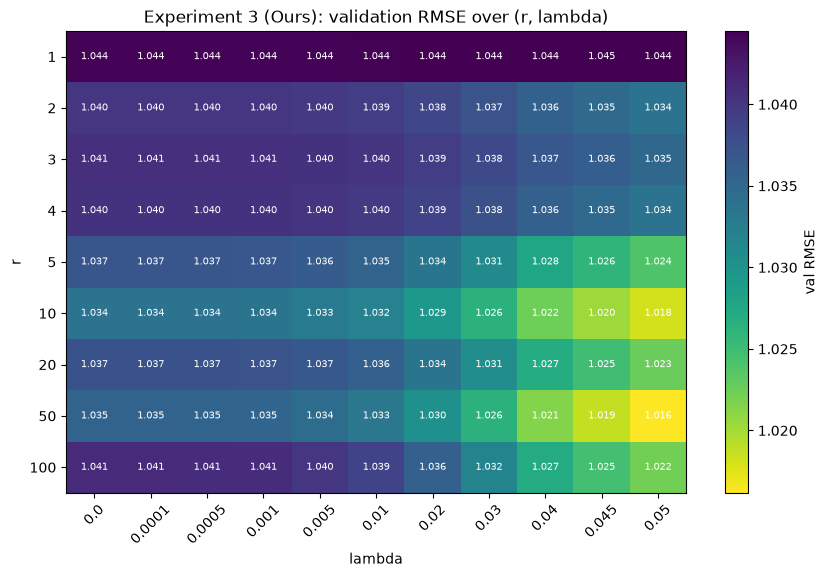

In [8]:
grid = np.array([[by_cfg[(r, lam)][5][-1] for lam in lam_values] for r in r_values])

plt.figure(figsize=(10, 6))
im = plt.imshow(grid, cmap="viridis_r", aspect="auto")
plt.xticks(range(len(lam_values)), lam_values, rotation=45)
plt.yticks(range(len(r_values)), r_values)
plt.xlabel("lambda")
plt.ylabel("r")
plt.title("Experiment 3 (Ours): validation RMSE over (r, lambda)")
plt.colorbar(im, label="val RMSE")
for i in range(len(r_values)):
    for j in range(len(lam_values)):
        plt.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="white", fontsize=7)
plt.show()

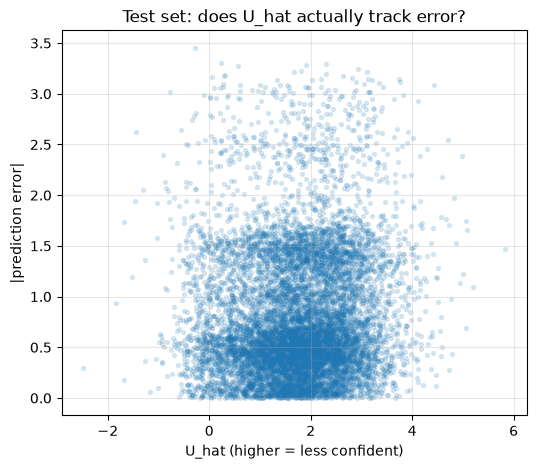

correlation(U_hat, |error|) = 0.0789


In [9]:
# a quick look at what the uncertainty head actually learned: does higher
# U (less confident) line up with bigger rating errors on the test set?
test_pred = mf_grid.predict(data["test_u"], data["test_m"], best_A, best_B, mean_val)
test_err = np.abs(test_pred - data["test_r"])
test_uhat = mf_grid.predict(data["test_u"], data["test_m"], best_C, best_D)

plt.figure(figsize=(6, 5))
plt.scatter(test_uhat, test_err, alpha=0.15, s=8)
plt.xlabel("U_hat (higher = less confident)")
plt.ylabel("|prediction error|")
plt.title("Test set: does U_hat actually track error?")
plt.grid(alpha=0.3)
plt.show()

print(f"correlation(U_hat, |error|) = {np.corrcoef(test_uhat, test_err)[0, 1]:.4f}")